In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


KAGGLE_INPUT = Path("/kaggle/input")

MANIFEST_PATH = next(
    KAGGLE_INPUT.rglob("zoolake_clean_split_manifest.csv")
)

OUTPUT_DIR = Path(
    "/kaggle/working/zoolake_class_distribution"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


print("Manifest:", MANIFEST_PATH)
print("Output:", OUTPUT_DIR)

Manifest: /kaggle/input/datasets/tsikaripunks/zoolake-clean-split-dataset/zoolake_clean_split_manifest.csv
Output: /kaggle/working/zoolake_class_distribution


In [2]:
manifest = pd.read_csv(MANIFEST_PATH)


# Μετράμε τις εικόνες κάθε κλάσης σε κάθε split.
distribution = pd.crosstab(
    manifest["label"],
    manifest["split"],
)


distribution = distribution.reindex(
    columns=[
        "train",
        "validation",
        "test",
    ],
    fill_value=0,
)


# Συνολικό πλήθος εικόνων κάθε κλάσης.
distribution["total"] = distribution.sum(axis=1)


print("Συνολικές εικόνες:", len(manifest))

print("\nΕικόνες ανά split:")
print(
    distribution[
        ["train", "validation", "test"]
    ].sum()
)

Συνολικές εικόνες: 17940

Εικόνες ανά split:
split
train         12558
validation     2691
test           2691
dtype: int64


In [3]:
distribution_table = (
    distribution
    .reset_index()
    .rename(
        columns={
            "label": "class",
            "train": "Train",
            "validation": "Validation",
            "test": "Test",
            "total": "Total",
        }
    )
)


distribution_table.to_csv(
    OUTPUT_DIR / "class_distribution.csv",
    index=False,
)


distribution_table

split,class,Train,Validation,Test,Total
0,aphanizomenon,164,28,33,225
1,asplanchna,410,93,103,606
2,asterionella,735,165,154,1054
3,bosmina,51,14,15,80
4,brachionus,93,21,23,137
5,ceratium,558,130,126,814
6,chaoborus,7,2,1,10
7,conochilus,189,42,33,264
8,copepod_skins,24,6,3,33
9,cyclops,591,148,127,866


In [4]:
full_table = (
    distribution
    .reset_index()
    .rename(
        columns={
            "label": "Κλάση",
            "train": "Εκπαίδευση",
            "validation": "Επικύρωση",
            "test": "Έλεγχος",
            "total": "Σύνολο",
        }
    )
)


# Πλήρης πίνακας για το Παράρτημα.
full_table.to_csv(
    OUTPUT_DIR / "full_class_distribution.csv",
    index=False,
)


# Κλάσεις με λιγότερες από 100 εικόνες συνολικά.
rare_table = full_table[
    full_table["Σύνολο"] < 100
].sort_values("Σύνολο")


rare_table.to_csv(
    OUTPUT_DIR / "rare_classes_distribution.csv",
    index=False,
)


print("Σπάνιες κλάσεις:")
rare_table

Σπάνιες κλάσεις:


split,Κλάση,Εκπαίδευση,Επικύρωση,Έλεγχος,Σύνολο
6,chaoborus,7,2,1,10
13,diatom_chain,12,3,2,17
20,hydra,15,1,2,18
8,copepod_skins,24,6,3,33
11,daphnia_skins,39,5,2,46
33,unknown_plankton,49,11,11,71
28,polyarthra,57,12,10,79
3,bosmina,51,14,15,80


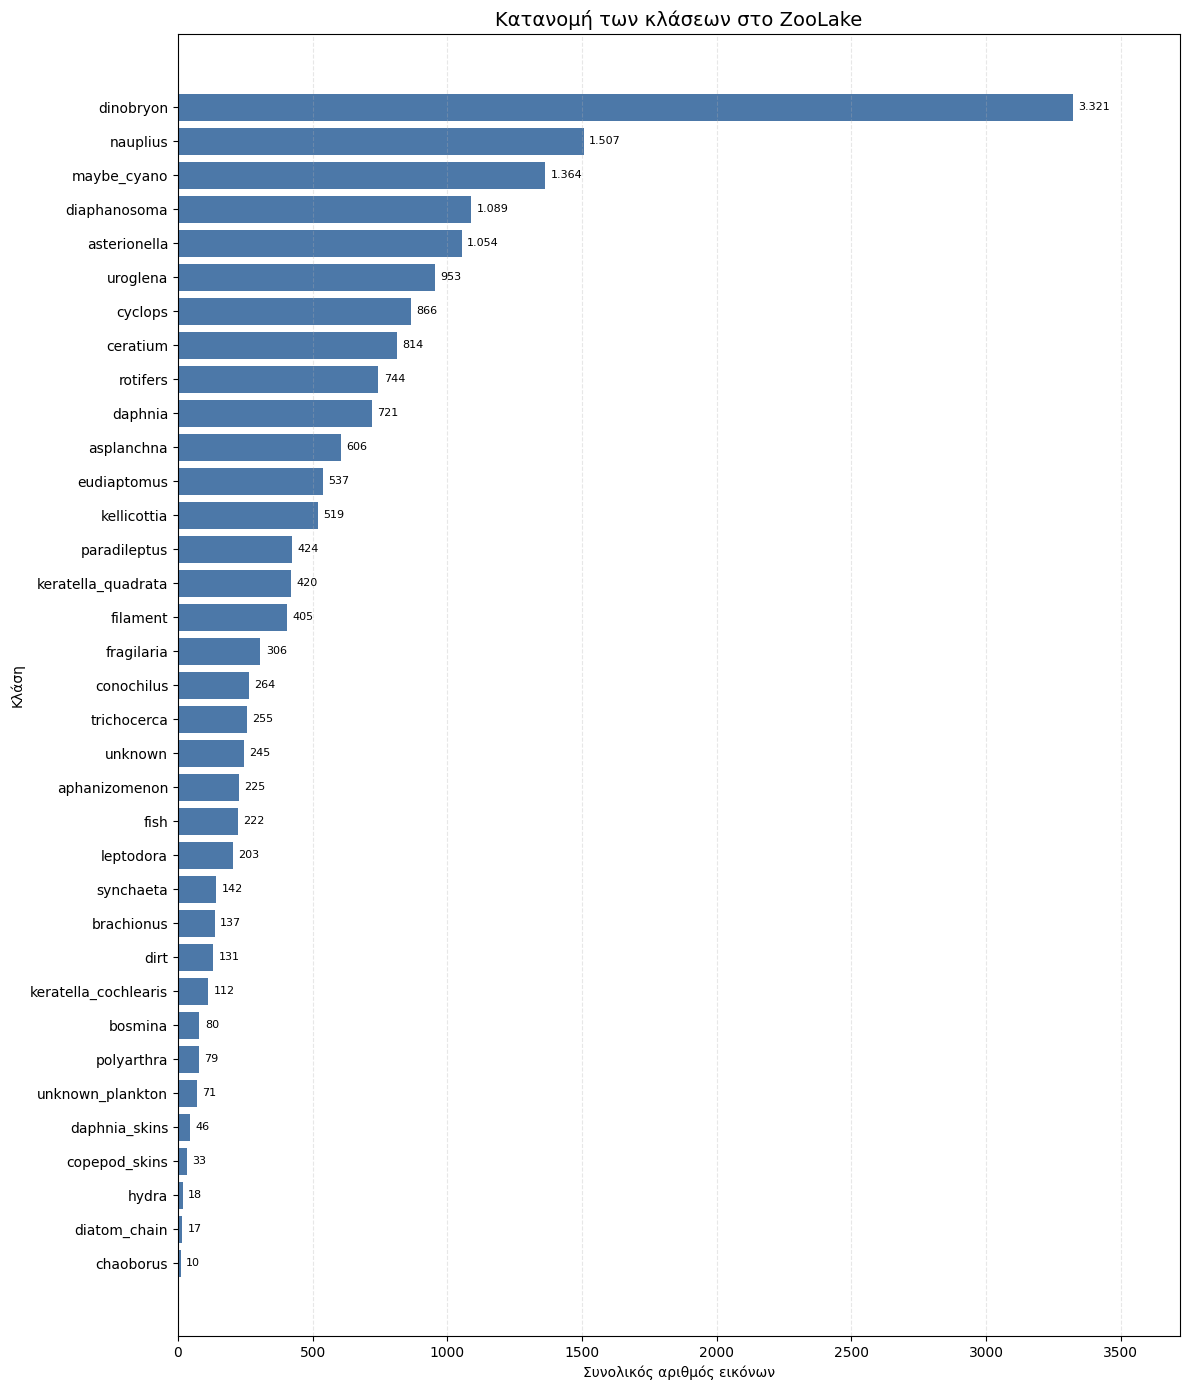

In [5]:
plot_data = distribution.sort_values(
    "total"
)


fig, ax = plt.subplots(
    figsize=(12, 14)
)


ax.barh(
    plot_data.index,
    plot_data["total"],
    color="#4C78A8",
)


maximum_total = plot_data["total"].max()


# Γράφουμε το συνολικό πλήθος δίπλα σε κάθε μπάρα.
for position, total in enumerate(
    plot_data["total"]
):
    total_text = f"{int(total):,}".replace(",", ".")

    ax.text(
        total + maximum_total * 0.006,
        position,
        total_text,
        va="center",
        fontsize=8,
    )


ax.set_title(
    "Κατανομή των κλάσεων στο ZooLake",
    fontsize=14,
)

ax.set_xlabel("Συνολικός αριθμός εικόνων")
ax.set_ylabel("Κλάση")

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.3,
)

ax.set_xlim(
    0,
    maximum_total * 1.12,
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "class_distribution_plot.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close()

In [6]:
full_table.to_excel(
    OUTPUT_DIR / "full_class_distribution.xlsx",
    index=False,
)

rare_table.to_excel(
    OUTPUT_DIR / "rare_classes_distribution.xlsx",
    index=False,
)